In [32]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



# start with some U_true and make it arrange.logpi

In [33]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
# centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [34]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [35]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

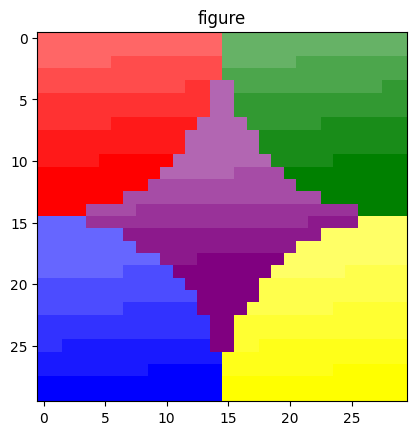

In [36]:
U_true_25 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_25 = pt.tensor(U_true_25, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_25)

plot_Us(U_true_25)

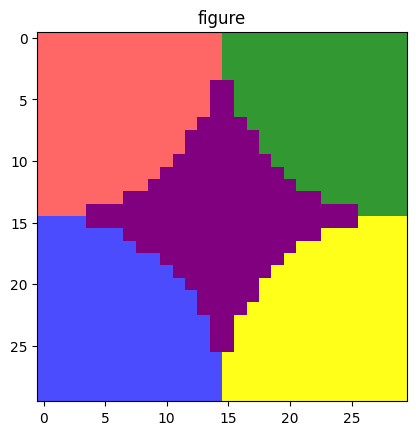

In [37]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, 1)
plot_Us(U_true_5)
U_true_5 = U_true_5[np.newaxis, :, :]

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

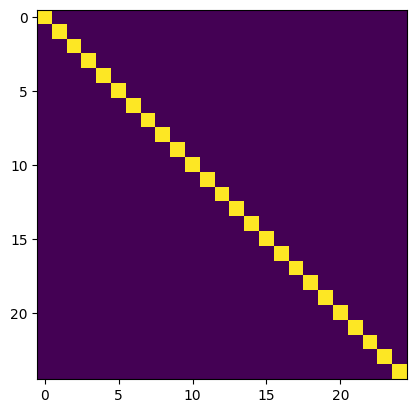

In [38]:
R= sim.custom_R(K_total =25, group_size=5, base_parcel_correlation=0.000, sub_parcel_extra_correlation=0.00)
plt.imshow(R)


covariance across tasks G

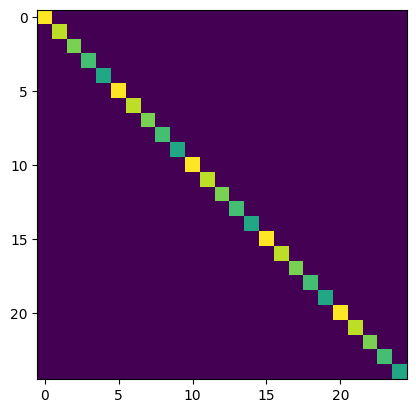

In [39]:
variance_factors = [[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6]]
# variance_factors = [[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]]
G = sim.custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.000, variance_factors=variance_factors)
plt.imshow(G)

make Vs (this num_iter gives a good V)

1.224744871395059
1.2247448713945073
1.2247448713921358
1.2247448713918219
1.224744871391697
1.2247448713916889
1.2247448713916855
1.2247448713916615
1.2247448713916516
1.2247448713916487
1.2247448713916478
1.2247448713916296
1.224744871391625
1.224744871391622


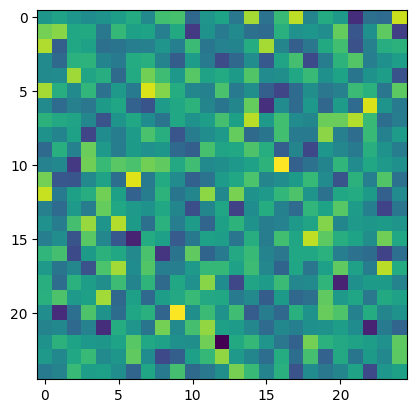

In [40]:
Vs_25= sim.find_best_V(G=G,R=R,num_iter=1600,rng = np.random.default_rng(101))
plt.imshow(Vs_25)


check covariance across rows and columns

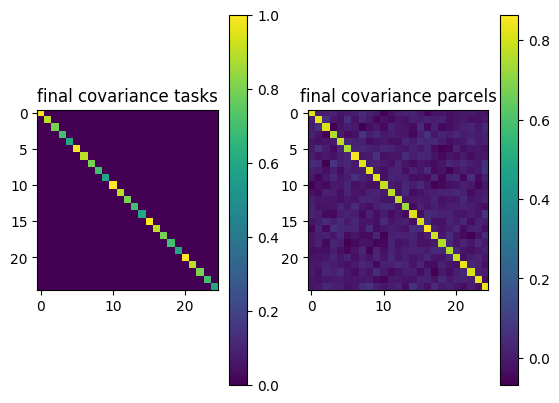

In [41]:
plt.subplot(1, 2, 1)
plt.imshow(Vs_25 @ Vs_25.T, cmap='viridis')
plt.colorbar()
plt.title('final covariance tasks')

plt.subplot(1, 2, 2)
plt.imshow(Vs_25.T @ Vs_25, cmap='viridis')
plt.colorbar()
plt.title('final covariance parcels')
plt.show()


lower dimensional Vs (just for the 5 main parcels)

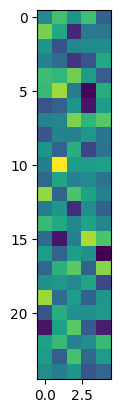

In [42]:
Vs_5 = Vs_25.reshape(25, 5, 5).mean(axis=2)
plt.imshow(Vs_5)

make true data

In [43]:
Y_true = Vs_25 @ np.array(U_true_25)


G matrix used for eigenmetrics

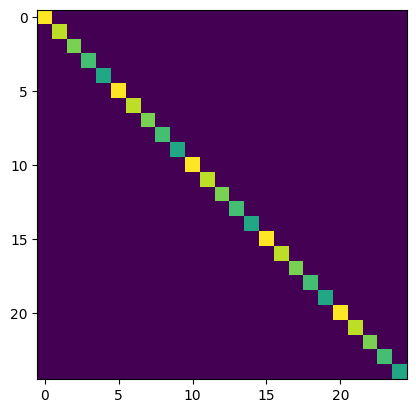

In [44]:
G_lib = Y_true @ Y_true.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

# Build combination dataframe

In [45]:
noise =0.15
vtest = Vs_5
ytest = Y_true + np.random.normal(0, noise, Y_true.shape)

In [46]:
D = ut.build_combinations(G_lib, strategy='balanced',n_iter=3000,n_tasks=8,seed=605,balanced_sampling_unique=[2,3,4,5,6,7,8])
D_ev = ev.evaluate_dataframe_simulation_multiregion(D,Y_true, Vs_5, U_true_5,sig_e=noise,vtest=vtest,ytest=ytest)

building0
Processing combination: 0
Processing combination: 1000
Processing combination: 2000


# Build model

0.8255977866024146


<Axes: xlabel='n_unique', ylabel='perc'>

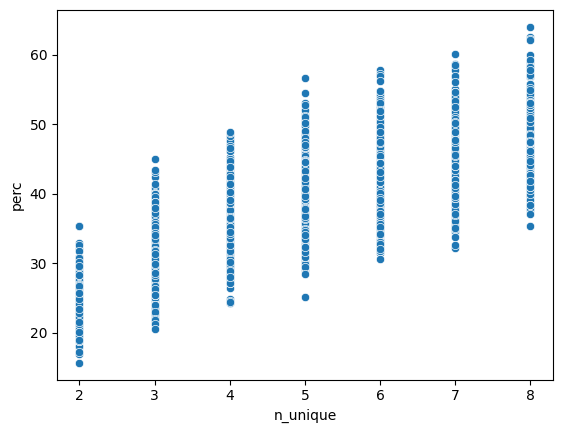

In [47]:
#correaltion 
corr = np.corrcoef(D_ev['n_unique'],D_ev['perc'])[0,1]
print(corr)
sns.scatterplot(data=D_ev, x='n_unique', y='perc')

In [48]:
n_unique_list = D_ev['n_unique'].unique()
n_unique_list.sort()
x = ['log_det','inverse_trace','variance']


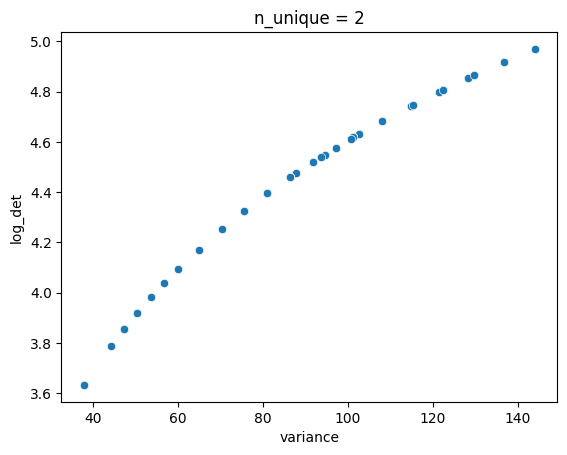

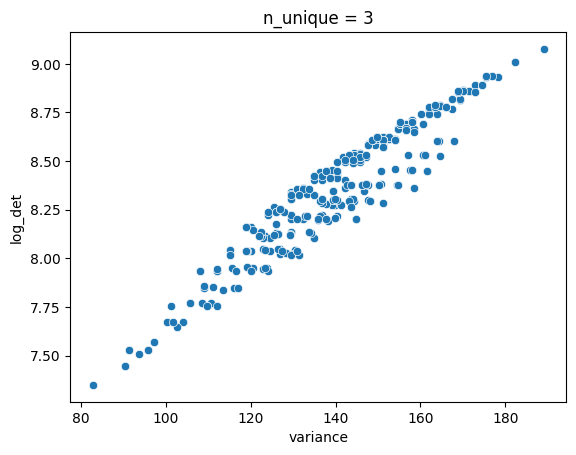

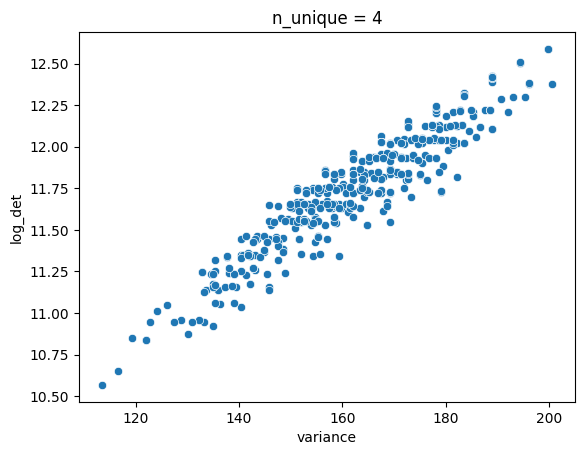

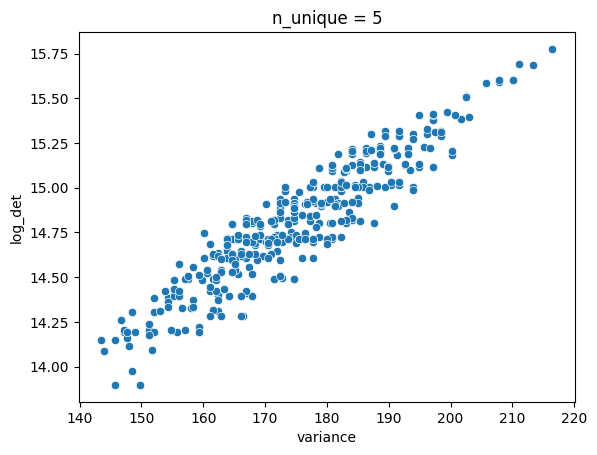

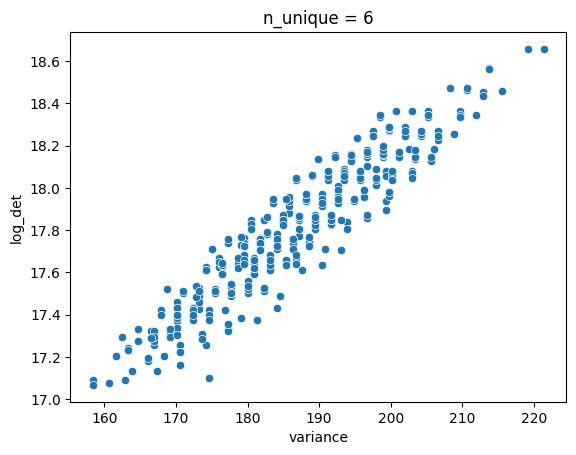

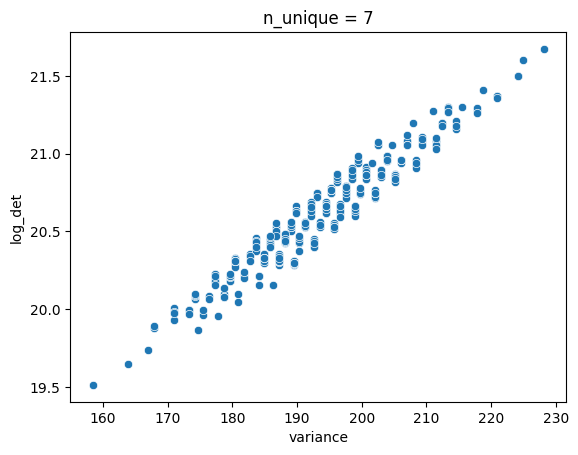

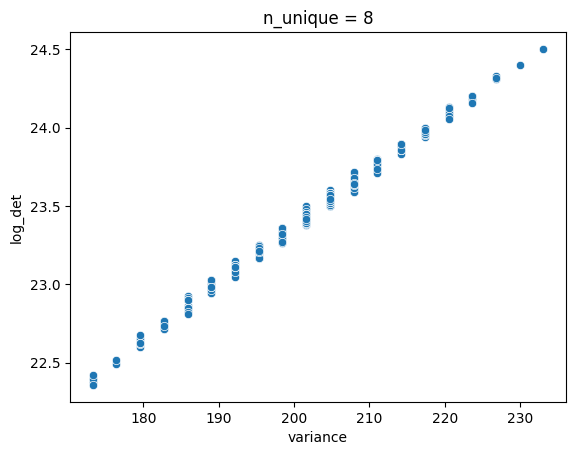

In [49]:
for i in n_unique_list:
    D_ev_temp = D_ev[D_ev['n_unique']==i]
    plt.figure()
    sns.scatterplot(data=D_ev_temp, x='variance', y='log_det')
    plt.title('n_unique = {}'.format(i))
    plt.show()

In [50]:
for i in n_unique_list:
    D_ev_temp = D_ev[D_ev['n_unique']==i]
    corr = np.corrcoef(D_ev_temp['variance'],D_ev_temp['perc'])[0,1]
    print(f'correlation of variance with perc for n_unique = {i} is {corr}')

correlation of variance with perc for n_unique = 2 is 0.14236725830869829
correlation of variance with perc for n_unique = 3 is 0.24059372903307472
correlation of variance with perc for n_unique = 4 is 0.29160080641971775
correlation of variance with perc for n_unique = 5 is 0.3706355212226057
correlation of variance with perc for n_unique = 6 is 0.36910730436829836
correlation of variance with perc for n_unique = 7 is 0.4368977969480954
correlation of variance with perc for n_unique = 8 is 0.4335443263156136


In [51]:
for i in n_unique_list:
    D_ev_temp = D_ev[D_ev['n_unique']==i]
    corr = np.corrcoef(D_ev_temp['log_det'],D_ev_temp['perc'])[0,1]
    print(f'correlation of log_det with perc for n_unique = {i} is {corr}')

correlation of log_det with perc for n_unique = 2 is 0.11859460876230092
correlation of log_det with perc for n_unique = 3 is 0.21539720933008324
correlation of log_det with perc for n_unique = 4 is 0.2687198986119221
correlation of log_det with perc for n_unique = 5 is 0.3527446838046849
correlation of log_det with perc for n_unique = 6 is 0.3630251491076378
correlation of log_det with perc for n_unique = 7 is 0.44162397801890485
correlation of log_det with perc for n_unique = 8 is 0.4246170153826503


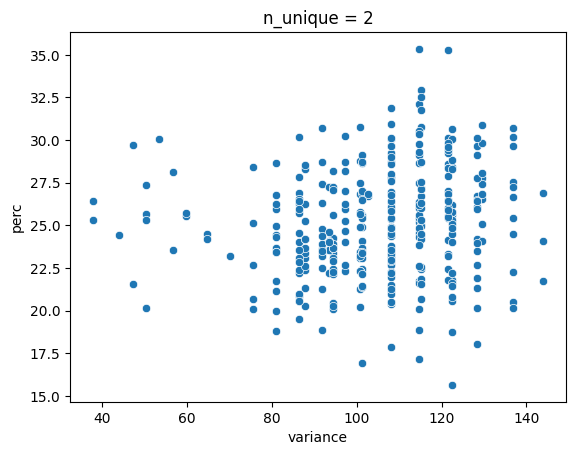

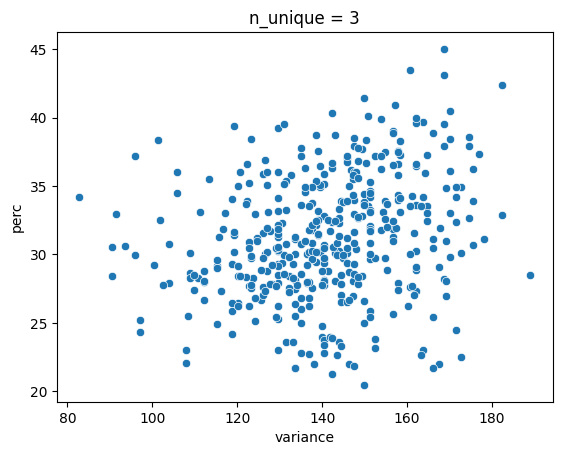

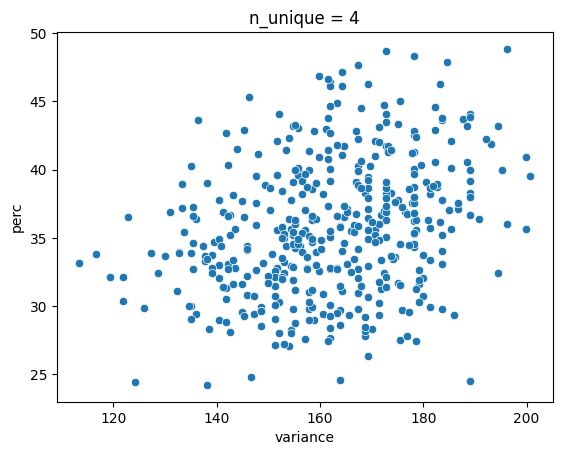

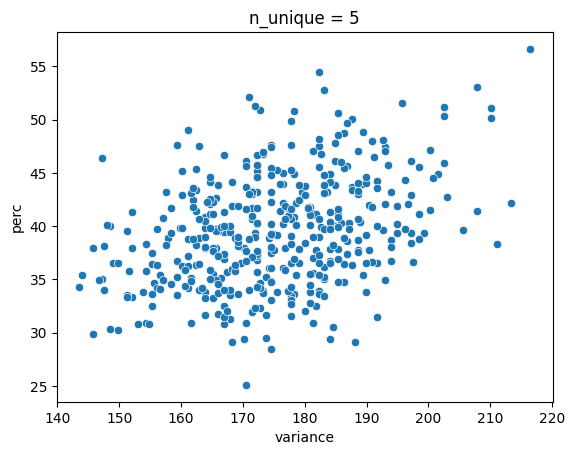

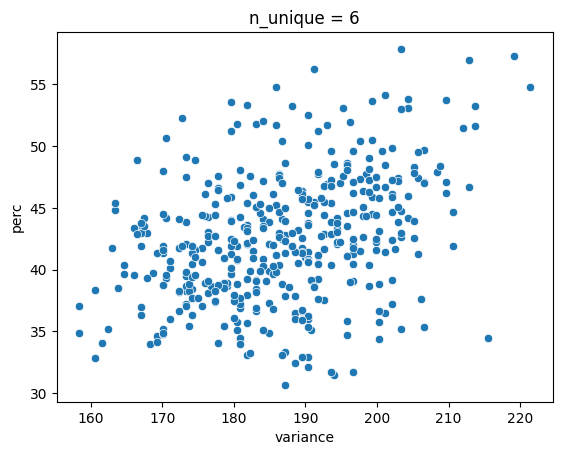

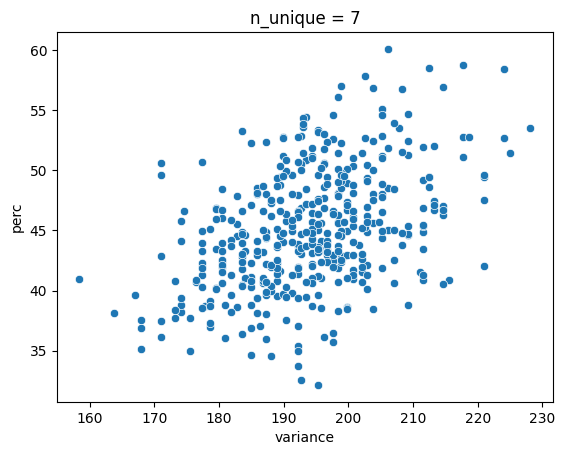

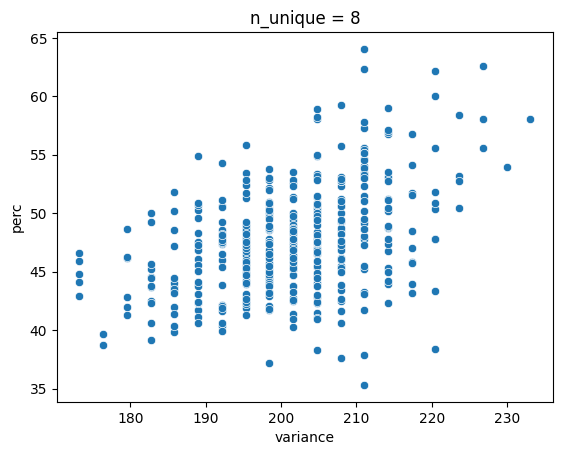

In [52]:
for i in n_unique_list:
    D_ev_temp = D_ev[D_ev['n_unique']==i]
    plt.figure()
    sns.scatterplot(data=D_ev_temp, x='variance', y='perc')
    plt.title('n_unique = {}'.format(i))
    plt.show()

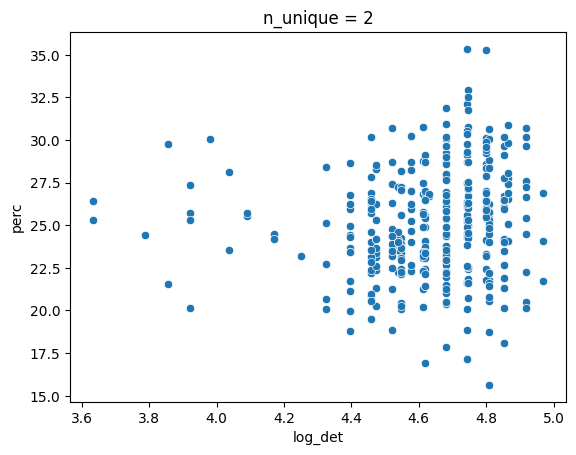

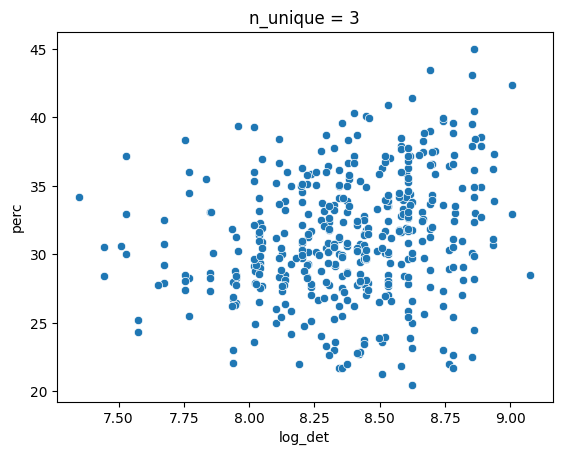

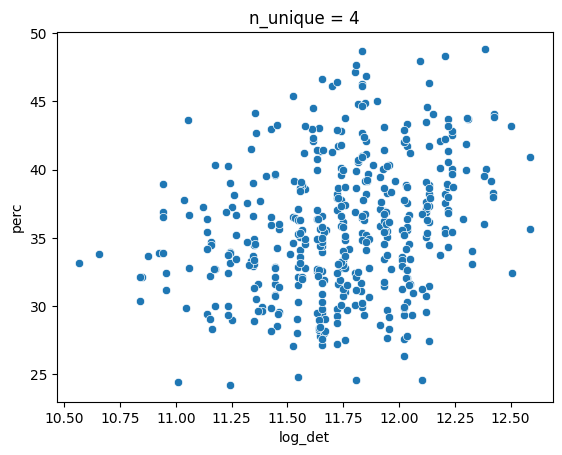

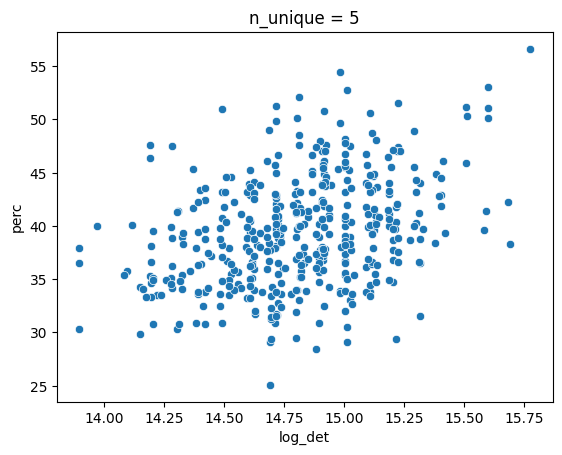

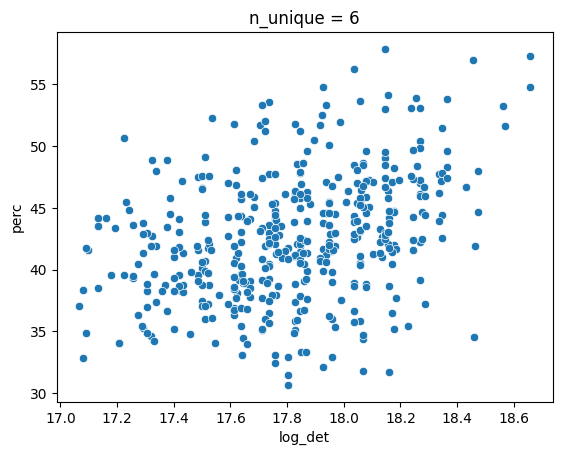

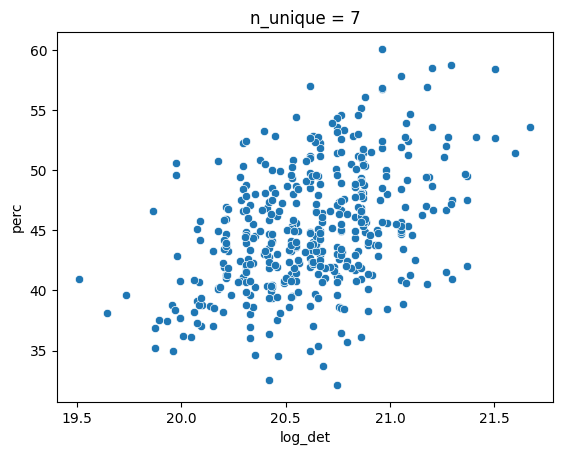

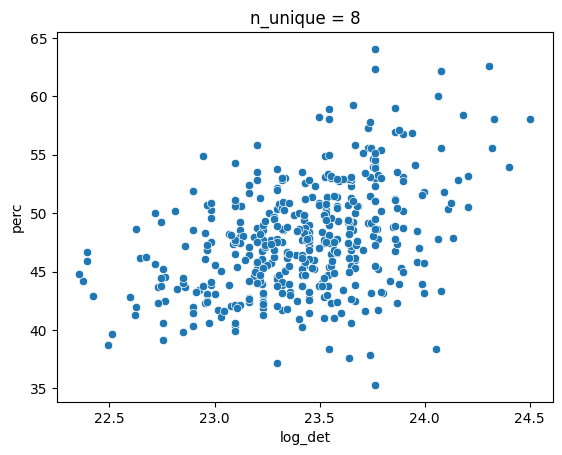

In [53]:
for i in n_unique_list:
    D_ev_temp = D_ev[D_ev['n_unique']==i]
    plt.figure()
    sns.scatterplot(data=D_ev_temp, x='log_det', y='perc')
    plt.title('n_unique = {}'.format(i))
    plt.show()